<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/notebooks/diffusion_boot_sequence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

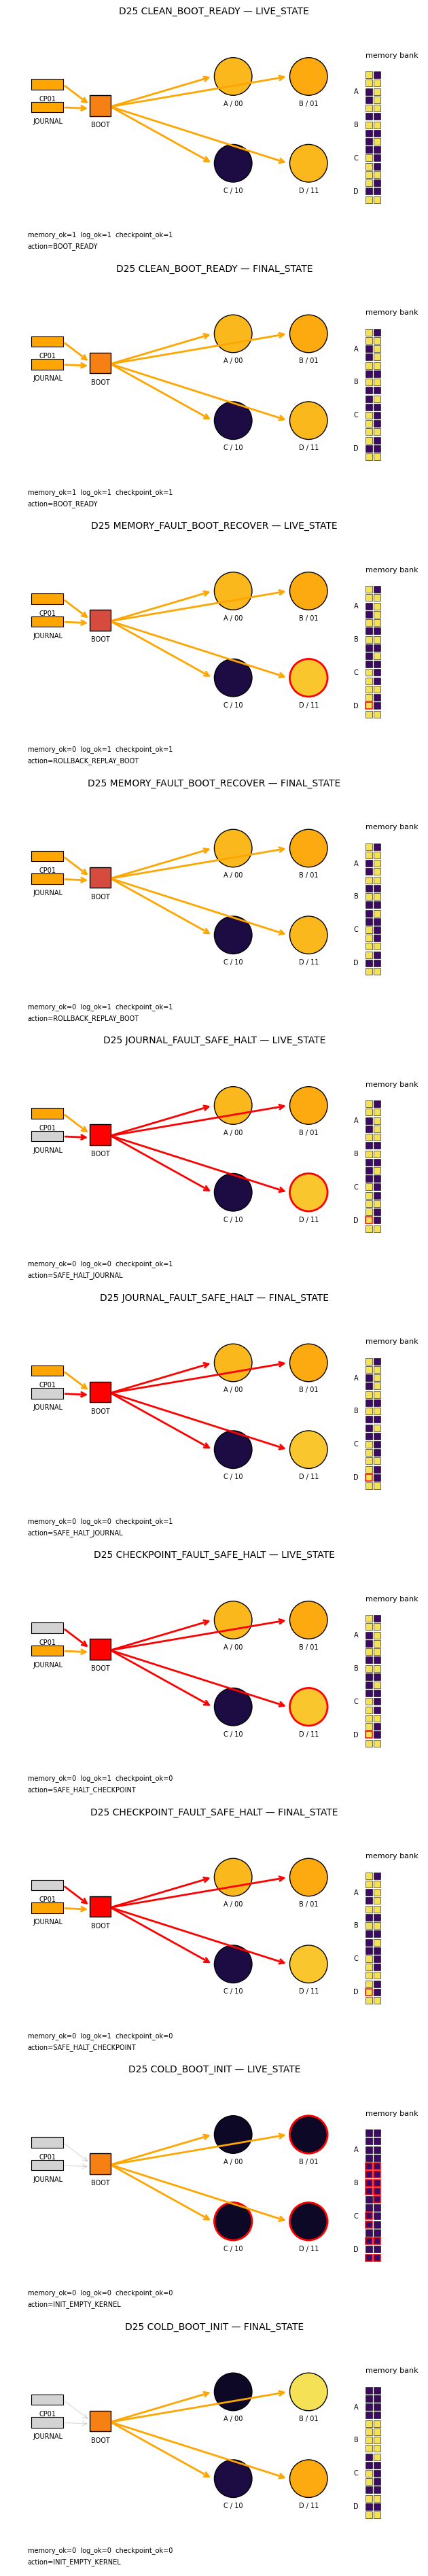

STATE: BOOT_SEQUENCE_LOCKED
cases tested:              5
locked cases:              5
checkpoint id:             CP01
checkpoint after tx:       TX01
clean final hash:          a1766a97aacc
checkpoint hash:           e28bf0576a7d

normal boot action:        BOOT_READY
memory fault action:       ROLLBACK_REPLAY_BOOT
journal broken action:     SAFE_HALT_JOURNAL
checkpoint broken action:  SAFE_HALT_CHECKPOINT
cold boot action:          INIT_EMPTY_KERNEL

Boot decision table:


,STATE,CASE,RESULT,ACTION,BOOT_MODE,MEMORY_OK,LOG_OK,CHECKPOINT_OK,REPLAYED_TX,LIVE_HASH,FINAL_HASH,EXPECTED_HASH,RECOVERED,LOCKED
0,D25_BOOT_SEQUENCE,CLEAN_BOOT_READY,BOOT_CASE_LOCKED,BOOT_READY,NORMAL_BOOT,1,1,1,0,a1766a97aacc,a1766a97aacc,a1766a97aacc,1,1
1,D25_BOOT_SEQUENCE,MEMORY_FAULT_BOOT_RECOVER,BOOT_CASE_LOCKED,ROLLBACK_REPLAY_BOOT,RECOVERY_BOOT,0,1,1,2,f599cc9d0415,a1766a97aacc,a1766a97aacc,1,1
2,D25_BOOT_SEQUENCE,JOURNAL_FAULT_SAFE_HALT,BOOT_CASE_LOCKED,SAFE_HALT_JOURNAL,SAFE_HALT,0,0,1,0,f599cc9d0415,f599cc9d0415,a1766a97aacc,0,1
3,D25_BOOT_SEQUENCE,CHECKPOINT_FAULT_SAFE_HALT,BOOT_CASE_LOCKED,SAFE_HALT_CHECKPOINT,SAFE_HALT,0,1,0,0,f599cc9d0415,f599cc9d0415,a1766a97aacc,0,1
4,D25_BOOT_SEQUENCE,COLD_BOOT_INIT,BOOT_CASE_LOCKED,INIT_EMPTY_KERNEL,COLD_INIT,0,0,0,0,5f94de6142cf,65d899a12613,65d899a12613,1,1



Per-cell boot result table:


,STATE,CASE,CELL,LIVE_SEQUENCE,FINAL_SEQUENCE,TARGET_SEQUENCE,FINAL_MATCH_TARGET
0,D25_BOOT_SEQUENCE,CLEAN_BOOT_READY,MEM_CELL_A,10110101,10110101,10110101,1
1,D25_BOOT_SEQUENCE,CLEAN_BOOT_READY,MEM_CELL_B,11001100,11001100,11001100,1
2,D25_BOOT_SEQUENCE,CLEAN_BOOT_READY,MEM_CELL_C,01001010,01001010,01001010,1
3,D25_BOOT_SEQUENCE,CLEAN_BOOT_READY,MEM_CELL_D,11100011,11100011,11100011,1
4,D25_BOOT_SEQUENCE,MEMORY_FAULT_BOOT_RECOVER,MEM_CELL_A,10110101,10110101,10110101,1
5,D25_BOOT_SEQUENCE,MEMORY_FAULT_BOOT_RECOVER,MEM_CELL_B,11001100,11001100,11001100,1
6,D25_BOOT_SEQUENCE,MEMORY_FAULT_BOOT_RECOVER,MEM_CELL_C,01001010,01001010,01001010,1
7,D25_BOOT_SEQUENCE,MEMORY_FAULT_BOOT_RECOVER,MEM_CELL_D,11101011,11100011,11100011,1
8,D25_BOOT_SEQUENCE,JOURNAL_FAULT_SAFE_HALT,MEM_CELL_A,10110101,10110101,10110101,1
9,D25_BOOT_SEQUENCE,JOURNAL_FAULT_SAFE_HALT,MEM_CELL_B,11001100,11001100,11001100,1



Clean hash-chain table:


,STATE,TX_ID,EXPECTED_PREV_HASH,LOG_PREV_HASH,EXPECTED_TX_HASH,LOG_TX_HASH,HASH_OK
0,D25_BOOT_SEQUENCE,TX00,GENESIS0000,GENESIS0000,773484660168,773484660168,1
1,D25_BOOT_SEQUENCE,TX01,773484660168,773484660168,5c33bfeefe6f,5c33bfeefe6f,1
2,D25_BOOT_SEQUENCE,TX02,5c33bfeefe6f,5c33bfeefe6f,6fec2d2ba008,6fec2d2ba008,1
3,D25_BOOT_SEQUENCE,TX03,6fec2d2ba008,6fec2d2ba008,794042bd95ce,794042bd95ce,1



Summary:


,STATE,RESULT,CASES_TESTED,LOCKED_CASES,CHECKPOINT_ID,CHECKPOINT_AFTER_TX,CLEAN_FINAL_HASH,CHECKPOINT_HASH,NORMAL_BOOT_ACTION,RECOVERY_BOOT_ACTION,JOURNAL_BROKEN_ACTION,CHECKPOINT_BROKEN_ACTION,COLD_BOOT_ACTION
0,D25_BOOT_SEQUENCE,BOOT_SEQUENCE_LOCKED,5,5,CP01,TX01,a1766a97aacc,e28bf0576a7d,BOOT_READY,ROLLBACK_REPLAY_BOOT,SAFE_HALT_JOURNAL,SAFE_HALT_CHECKPOINT,INIT_EMPTY_KERNEL


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hashlib
from copy import deepcopy
from IPython.display import display
from matplotlib.patches import Circle, Rectangle, FancyArrowPatch

# ============================================================
# D25_BOOT_SEQUENCE
# Field kernel boot sequence and startup recovery
#
# Goal:
# power-on
# -> verify checkpoint
# -> verify transaction journal
# -> verify live memory
# -> decide boot action
# -> continue, recover, safe-halt, or cold-init
# ============================================================

np.random.seed(25)

STATE = "D25_BOOT_SEQUENCE"

address_map = {
    "00": "MEM_CELL_A",
    "01": "MEM_CELL_B",
    "10": "MEM_CELL_C",
    "11": "MEM_CELL_D",
}

memory_initial = {
    "MEM_CELL_A": "00000000",
    "MEM_CELL_B": "11111111",
    "MEM_CELL_C": "01001010",
    "MEM_CELL_D": "00110011",
}

transactions = [
    {
        "TX_ID": "TX00",
        "OP": "WRITE",
        "WRITER": "A",
        "ADDR_A": "00",
        "ADDR_B": "",
        "PAYLOAD_A": "10110101",
        "PAYLOAD_B": "",
        "WINNER": "A",
    },
    {
        "TX_ID": "TX01",
        "OP": "WRITE",
        "WRITER": "B",
        "ADDR_A": "",
        "ADDR_B": "10",
        "PAYLOAD_A": "",
        "PAYLOAD_B": "01001010",
        "WINNER": "B",
    },
    {
        "TX_ID": "TX02",
        "OP": "WRITE",
        "WRITER": "B",
        "ADDR_A": "",
        "ADDR_B": "01",
        "PAYLOAD_A": "",
        "PAYLOAD_B": "11001100",
        "WINNER": "B",
    },
    {
        "TX_ID": "TX03",
        "OP": "COLLISION_WRITE",
        "WRITER": "A+B",
        "ADDR_A": "11",
        "ADDR_B": "11",
        "PAYLOAD_A": "11100011",
        "PAYLOAD_B": "00011100",
        "WINNER": "A",
    },
]

checkpoint_after_tx = "TX01"
checkpoint_id = "CP01"


def seq_to_bits(seq):
    return [int(x) for x in seq]


def bits_to_string(bits):
    return "".join(str(int(x)) for x in bits)


def short_hash(text, length=12):
    return hashlib.sha256(str(text).encode("utf-8")).hexdigest()[:length]


def memory_hash(memory):
    payload = "|".join(f"{k}:{memory[k]}" for k in sorted(memory.keys()))
    return short_hash(payload)


def tx_hash(prev_hash, tx_id, op, writer, selected_cell, before_seq, payload, after_seq, result):
    payload_text = "|".join([
        prev_hash,
        tx_id,
        op,
        writer,
        selected_cell,
        before_seq,
        payload,
        after_seq,
        result,
    ])
    return short_hash(payload_text)


def decode_selected_cell(tx):
    if tx["WINNER"] == "A":
        return address_map[tx["ADDR_A"]]
    if tx["WINNER"] == "B":
        return address_map[tx["ADDR_B"]]
    return None


def decode_payload(tx):
    if tx["WINNER"] == "A":
        return tx["PAYLOAD_A"]
    if tx["WINNER"] == "B":
        return tx["PAYLOAD_B"]
    return ""


def apply_transaction(memory, tx):
    next_memory = deepcopy(memory)

    selected_cell = decode_selected_cell(tx)
    payload = decode_payload(tx)

    before_seq = next_memory[selected_cell]
    next_memory[selected_cell] = payload
    after_seq = next_memory[selected_cell]

    if tx["OP"] == "COLLISION_WRITE":
        result = "COLLISION_ARBITRATED"
    else:
        result = "COMMITTED"

    return next_memory, {
        "TX_ID": tx["TX_ID"],
        "OP": tx["OP"],
        "WRITER": tx["WRITER"],
        "ADDR_A": tx["ADDR_A"],
        "ADDR_B": tx["ADDR_B"],
        "SELECTED_CELL": selected_cell,
        "WINNER": tx["WINNER"],
        "BEFORE_SEQUENCE": before_seq,
        "PAYLOAD_WRITTEN": payload,
        "AFTER_SEQUENCE": after_seq,
        "RESULT": result,
    }


def build_journal_and_states(initial_memory, txs):
    memory = deepcopy(initial_memory)
    states_after = {}
    rows = []
    prev_hash = "GENESIS0000"

    for tx in txs:
        memory, row = apply_transaction(memory, tx)

        row["PREV_HASH"] = prev_hash
        row["TX_HASH"] = tx_hash(
            prev_hash,
            row["TX_ID"],
            row["OP"],
            row["WRITER"],
            row["SELECTED_CELL"],
            row["BEFORE_SEQUENCE"],
            row["PAYLOAD_WRITTEN"],
            row["AFTER_SEQUENCE"],
            row["RESULT"],
        )

        prev_hash = row["TX_HASH"]
        states_after[row["TX_ID"]] = deepcopy(memory)
        rows.append(row)

    return memory, pd.DataFrame(rows), states_after


def verify_journal(journal_df):
    check_rows = []
    prev_hash = "GENESIS0000"
    ok = True

    for _, row in journal_df.iterrows():
        expected_hash = tx_hash(
            prev_hash,
            row["TX_ID"],
            row["OP"],
            row["WRITER"],
            row["SELECTED_CELL"],
            row["BEFORE_SEQUENCE"],
            row["PAYLOAD_WRITTEN"],
            row["AFTER_SEQUENCE"],
            row["RESULT"],
        )

        hash_ok = int(prev_hash == row["PREV_HASH"] and expected_hash == row["TX_HASH"])
        ok = ok and bool(hash_ok)

        check_rows.append({
            "STATE": STATE,
            "TX_ID": row["TX_ID"],
            "EXPECTED_PREV_HASH": prev_hash,
            "LOG_PREV_HASH": row["PREV_HASH"],
            "EXPECTED_TX_HASH": expected_hash,
            "LOG_TX_HASH": row["TX_HASH"],
            "HASH_OK": hash_ok,
        })

        prev_hash = row["TX_HASH"]

    return ok, pd.DataFrame(check_rows)


def replay_from_checkpoint(checkpoint_memory, journal_df, after_tx_id):
    memory = deepcopy(checkpoint_memory)

    tx_ids = list(journal_df["TX_ID"])
    start_index = tx_ids.index(after_tx_id) + 1

    replayed = 0
    for _, row in journal_df.iloc[start_index:].iterrows():
        selected_cell = row["SELECTED_CELL"]
        payload = row["PAYLOAD_WRITTEN"]
        memory[selected_cell] = payload
        replayed += 1

    return memory, replayed


def flip_bit_in_sequence(seq, slot):
    bits = seq_to_bits(seq)
    bits[slot] = 1 - bits[slot]
    return bits_to_string(bits)


# ------------------------------------------------------------
# Build clean reference state
# ------------------------------------------------------------

clean_final_memory, clean_journal, states_after_tx = build_journal_and_states(memory_initial, transactions)

checkpoint_memory = deepcopy(states_after_tx[checkpoint_after_tx])
checkpoint_hash = memory_hash(checkpoint_memory)
clean_final_hash = memory_hash(clean_final_memory)

journal_ok_clean, clean_hash_table = verify_journal(clean_journal)


# ------------------------------------------------------------
# Boot case preparation
# ------------------------------------------------------------

memory_fault = deepcopy(clean_final_memory)
memory_fault["MEM_CELL_D"] = flip_bit_in_sequence(memory_fault["MEM_CELL_D"], 4)

journal_fault = clean_journal.copy()
journal_fault.loc[journal_fault["TX_ID"] == "TX02", "TX_HASH"] = "BROKEN_HASH"

checkpoint_fault = deepcopy(checkpoint_memory)
checkpoint_fault["MEM_CELL_C"] = flip_bit_in_sequence(checkpoint_fault["MEM_CELL_C"], 2)

blank_memory = {cell: "00000000" for cell in memory_initial}

boot_cases = [
    {
        "CASE": "CLEAN_BOOT_READY",
        "LIVE_MEMORY": deepcopy(clean_final_memory),
        "JOURNAL": clean_journal.copy(),
        "CHECKPOINT": deepcopy(checkpoint_memory),
        "CHECKPOINT_PRESENT": True,
        "JOURNAL_PRESENT": True,
    },
    {
        "CASE": "MEMORY_FAULT_BOOT_RECOVER",
        "LIVE_MEMORY": deepcopy(memory_fault),
        "JOURNAL": clean_journal.copy(),
        "CHECKPOINT": deepcopy(checkpoint_memory),
        "CHECKPOINT_PRESENT": True,
        "JOURNAL_PRESENT": True,
    },
    {
        "CASE": "JOURNAL_FAULT_SAFE_HALT",
        "LIVE_MEMORY": deepcopy(memory_fault),
        "JOURNAL": journal_fault.copy(),
        "CHECKPOINT": deepcopy(checkpoint_memory),
        "CHECKPOINT_PRESENT": True,
        "JOURNAL_PRESENT": True,
    },
    {
        "CASE": "CHECKPOINT_FAULT_SAFE_HALT",
        "LIVE_MEMORY": deepcopy(memory_fault),
        "JOURNAL": clean_journal.copy(),
        "CHECKPOINT": deepcopy(checkpoint_fault),
        "CHECKPOINT_PRESENT": True,
        "JOURNAL_PRESENT": True,
    },
    {
        "CASE": "COLD_BOOT_INIT",
        "LIVE_MEMORY": deepcopy(blank_memory),
        "JOURNAL": pd.DataFrame(columns=clean_journal.columns),
        "CHECKPOINT": {},
        "CHECKPOINT_PRESENT": False,
        "JOURNAL_PRESENT": False,
    },
]


# ------------------------------------------------------------
# Boot controller
# ------------------------------------------------------------

boot_rows = []
cell_rows = []
boot_artifacts = {}

for case in boot_cases:
    case_name = case["CASE"]
    live_memory = deepcopy(case["LIVE_MEMORY"])
    live_hash = memory_hash(live_memory)

    if case["JOURNAL_PRESENT"]:
        log_ok, log_check_table = verify_journal(case["JOURNAL"])
    else:
        log_ok = False
        log_check_table = pd.DataFrame()

    if case["CHECKPOINT_PRESENT"]:
        cp_hash = memory_hash(case["CHECKPOINT"])
        checkpoint_ok = cp_hash == checkpoint_hash
    else:
        cp_hash = "NO_CHECKPOINT"
        checkpoint_ok = False

    memory_ok = live_hash == clean_final_hash

    replayed_tx = 0

    if case_name == "COLD_BOOT_INIT":
        action = "INIT_EMPTY_KERNEL"
        final_memory = deepcopy(memory_initial)
        boot_mode = "COLD_INIT"
        recovered = True

    elif memory_ok and log_ok and checkpoint_ok:
        action = "BOOT_READY"
        final_memory = deepcopy(live_memory)
        boot_mode = "NORMAL_BOOT"
        recovered = True

    elif (not memory_ok) and log_ok and checkpoint_ok:
        action = "ROLLBACK_REPLAY_BOOT"
        final_memory, replayed_tx = replay_from_checkpoint(
            case["CHECKPOINT"],
            case["JOURNAL"],
            checkpoint_after_tx
        )
        boot_mode = "RECOVERY_BOOT"
        recovered = memory_hash(final_memory) == clean_final_hash

    elif not log_ok:
        action = "SAFE_HALT_JOURNAL"
        final_memory = deepcopy(live_memory)
        boot_mode = "SAFE_HALT"
        recovered = False

    elif not checkpoint_ok:
        action = "SAFE_HALT_CHECKPOINT"
        final_memory = deepcopy(live_memory)
        boot_mode = "SAFE_HALT"
        recovered = False

    else:
        action = "SAFE_HALT_UNKNOWN"
        final_memory = deepcopy(live_memory)
        boot_mode = "SAFE_HALT"
        recovered = False

    final_hash = memory_hash(final_memory)

    if boot_mode == "COLD_INIT":
        expected_hash = memory_hash(memory_initial)
        locked = recovered and final_hash == expected_hash
    elif boot_mode == "SAFE_HALT":
        expected_hash = clean_final_hash
        locked = action.startswith("SAFE_HALT") and recovered == False
    else:
        expected_hash = clean_final_hash
        locked = recovered and final_hash == expected_hash

    boot_rows.append({
        "STATE": STATE,
        "CASE": case_name,
        "RESULT": "BOOT_CASE_LOCKED" if locked else "BOOT_CASE_PARTIAL",
        "ACTION": action,
        "BOOT_MODE": boot_mode,
        "MEMORY_OK": int(memory_ok),
        "LOG_OK": int(log_ok),
        "CHECKPOINT_OK": int(checkpoint_ok),
        "REPLAYED_TX": replayed_tx,
        "LIVE_HASH": live_hash,
        "FINAL_HASH": final_hash,
        "EXPECTED_HASH": expected_hash,
        "RECOVERED": int(recovered),
        "LOCKED": int(locked),
    })

    for cell in memory_initial:
        clean_target = memory_initial[cell] if boot_mode == "COLD_INIT" else clean_final_memory[cell]

        cell_rows.append({
            "STATE": STATE,
            "CASE": case_name,
            "CELL": cell,
            "LIVE_SEQUENCE": live_memory[cell],
            "FINAL_SEQUENCE": final_memory[cell],
            "TARGET_SEQUENCE": clean_target,
            "FINAL_MATCH_TARGET": int(final_memory[cell] == clean_target),
        })

    boot_artifacts[case_name] = {
        "live": live_memory,
        "final": final_memory,
        "action": action,
        "boot_mode": boot_mode,
        "memory_ok": memory_ok,
        "log_ok": log_ok,
        "checkpoint_ok": checkpoint_ok,
    }

df_boot = pd.DataFrame(boot_rows)
df_cells = pd.DataFrame(cell_rows)

result = "BOOT_SEQUENCE_LOCKED" if int(df_boot["LOCKED"].sum()) == len(df_boot) else "BOOT_SEQUENCE_PARTIAL"

df_summary = pd.DataFrame([{
    "STATE": STATE,
    "RESULT": result,
    "CASES_TESTED": len(df_boot),
    "LOCKED_CASES": int(df_boot["LOCKED"].sum()),
    "CHECKPOINT_ID": checkpoint_id,
    "CHECKPOINT_AFTER_TX": checkpoint_after_tx,
    "CLEAN_FINAL_HASH": clean_final_hash,
    "CHECKPOINT_HASH": checkpoint_hash,
    "NORMAL_BOOT_ACTION": "BOOT_READY",
    "RECOVERY_BOOT_ACTION": "ROLLBACK_REPLAY_BOOT",
    "JOURNAL_BROKEN_ACTION": "SAFE_HALT_JOURNAL",
    "CHECKPOINT_BROKEN_ACTION": "SAFE_HALT_CHECKPOINT",
    "COLD_BOOT_ACTION": "INIT_EMPTY_KERNEL",
}])


# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

def bit_color(bit, intensity=1.0):
    if bit == 1:
        return plt.cm.inferno(0.70 + 0.22 * intensity)
    return plt.cm.inferno(0.07 + 0.12 * intensity)


cell_positions = {
    "MEM_CELL_A": (6.0, 5.9),
    "MEM_CELL_B": (8.0, 5.9),
    "MEM_CELL_C": (6.0, 3.6),
    "MEM_CELL_D": (8.0, 3.6),
}

address_labels = {
    "MEM_CELL_A": "A / 00",
    "MEM_CELL_B": "B / 01",
    "MEM_CELL_C": "C / 10",
    "MEM_CELL_D": "D / 11",
}


def draw_bank_grid(ax, x0, y0, memory, title, target_memory=None):
    cell = 0.18
    gap = 0.04

    ax.text(x0, y0 + 3.85, title, fontsize=8, ha="left", color="black")

    cell_names = list(memory.keys())
    for bank_index, cell_name in enumerate(cell_names):
        seq = memory[cell_name]
        target_seq = target_memory[cell_name] if target_memory else seq

        for i, bit in enumerate(seq_to_bits(seq)):
            col = i % 2
            row = i // 2

            x = x0 + col * (cell + gap)
            y = y0 + (len(cell_names) - 1 - bank_index) * 0.88 + (3 - row) * (cell + gap)

            edge = "red" if seq[i] != target_seq[i] else "black"
            lw = 1.1 if seq[i] != target_seq[i] else 0.4

            ax.add_patch(Rectangle(
                (x, y),
                cell,
                cell,
                facecolor=bit_color(int(bit)),
                edgecolor=edge,
                linewidth=lw
            ))

        ax.text(x0 - 0.18, y0 + (len(cell_names) - 1 - bank_index) * 0.88 + 0.25, cell_name[-1], fontsize=7, ha="right")


def draw_arrow(ax, start, end, active=True, fault=False):
    color = "red" if fault else "orange" if active else "gray"
    alpha = 1.0 if active or fault else 0.25
    lw = 2.0 if active or fault else 1.0

    ax.add_patch(FancyArrowPatch(
        start,
        end,
        arrowstyle="->",
        mutation_scale=12,
        linewidth=lw,
        color=color,
        alpha=alpha
    ))


def draw_boot_snapshot(ax, case_name, view, t):
    artifact = boot_artifacts[case_name]

    memory = artifact[view]
    action = artifact["action"]
    boot_mode = artifact["boot_mode"]
    memory_ok = artifact["memory_ok"]
    log_ok = artifact["log_ok"]
    checkpoint_ok = artifact["checkpoint_ok"]

    ax.set_facecolor("white")
    ax.set_xlim(0, 11)
    ax.set_ylim(1.2, 7.4)
    ax.set_aspect("equal")
    ax.axis("off")

    is_safe_halt = boot_mode == "SAFE_HALT"
    is_recovery = boot_mode == "RECOVERY_BOOT"
    is_cold = boot_mode == "COLD_INIT"

    ctrl_color = "red" if is_safe_halt else plt.cm.inferno(0.58 if is_recovery else 0.72)
    cp_color = "orange" if checkpoint_ok else "lightgray"
    log_color = "orange" if log_ok else "lightgray"

    if is_cold:
        cp_color = "lightgray"
        log_color = "lightgray"

    ax.add_patch(Rectangle((0.65, 5.55), 0.85, 0.28, facecolor=cp_color, edgecolor="black", linewidth=0.8))
    ax.text(1.08, 5.25, checkpoint_id, fontsize=7, ha="center")

    ax.add_patch(Rectangle((0.65, 4.95), 0.85, 0.28, facecolor=log_color, edgecolor="black", linewidth=0.8))
    ax.text(1.08, 4.65, "JOURNAL", fontsize=7, ha="center")

    ax.add_patch(Rectangle((2.2, 4.85), 0.55, 0.55, facecolor=ctrl_color, edgecolor="black", linewidth=1.0))
    ax.text(2.48, 4.55, "BOOT", fontsize=7, ha="center")

    draw_arrow(ax, (1.5, 5.68), (2.2, 5.15), active=checkpoint_ok, fault=not checkpoint_ok and not is_cold)
    draw_arrow(ax, (1.5, 5.08), (2.2, 5.05), active=log_ok, fault=not log_ok and not is_cold)

    target_memory = memory_initial if is_cold else clean_final_memory

    for cell_name, pos in cell_positions.items():
        seq = memory[cell_name]
        target = target_memory[cell_name]
        mean_bit = np.mean(seq_to_bits(seq))
        mismatch = seq != target

        color = bit_color(1 if mean_bit >= 0.5 else 0, mean_bit)
        edge = "red" if mismatch and view == "live" else "black"
        lw = 2.0 if mismatch and view == "live" else 1.0

        ax.add_patch(Circle(pos, 0.50, facecolor=color, edgecolor=edge, linewidth=lw))
        ax.text(pos[0], pos[1] - 0.78, address_labels[cell_name], fontsize=7, ha="center")

        route_fault = is_safe_halt
        route_active = not is_safe_halt
        draw_arrow(ax, (2.75, 5.1), (pos[0] - 0.55, pos[1]), active=route_active, fault=route_fault)

    draw_bank_grid(ax, 9.5, 2.55, memory, "memory bank", target_memory=target_memory)

    flags = f"memory_ok={int(memory_ok)}  log_ok={int(log_ok)}  checkpoint_ok={int(checkpoint_ok)}"
    ax.text(0.55, 1.65, flags, fontsize=7, ha="left", color="black")
    ax.text(0.55, 1.35, f"action={action}", fontsize=7, ha="left", color="black")

    ax.set_title(f"D25 {case_name} — {view.upper()}_STATE", fontsize=10, color="black")


snapshots = [
    ("CLEAN_BOOT_READY", "live", 0),
    ("CLEAN_BOOT_READY", "final", 120),
    ("MEMORY_FAULT_BOOT_RECOVER", "live", 260),
    ("MEMORY_FAULT_BOOT_RECOVER", "final", 420),
    ("JOURNAL_FAULT_SAFE_HALT", "live", 560),
    ("JOURNAL_FAULT_SAFE_HALT", "final", 700),
    ("CHECKPOINT_FAULT_SAFE_HALT", "live", 840),
    ("CHECKPOINT_FAULT_SAFE_HALT", "final", 980),
    ("COLD_BOOT_INIT", "live", 1120),
    ("COLD_BOOT_INIT", "final", 1260),
]

fig, axes = plt.subplots(len(snapshots), 1, figsize=(7, 3.8 * len(snapshots)))

for ax, (case_name, view, t) in zip(axes, snapshots):
    draw_boot_snapshot(ax, case_name, view, t)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

print(f"STATE: {result}")
print(f"cases tested:              {len(df_boot)}")
print(f"locked cases:              {int(df_boot['LOCKED'].sum())}")
print(f"checkpoint id:             {checkpoint_id}")
print(f"checkpoint after tx:       {checkpoint_after_tx}")
print(f"clean final hash:          {clean_final_hash}")
print(f"checkpoint hash:           {checkpoint_hash}")
print("")
print("normal boot action:        BOOT_READY")
print("memory fault action:       ROLLBACK_REPLAY_BOOT")
print("journal broken action:     SAFE_HALT_JOURNAL")
print("checkpoint broken action:  SAFE_HALT_CHECKPOINT")
print("cold boot action:          INIT_EMPTY_KERNEL")

print("\nBoot decision table:")
display(df_boot)

print("\nPer-cell boot result table:")
display(df_cells)

print("\nClean hash-chain table:")
display(clean_hash_table)

print("\nSummary:")
display(df_summary)